In [1]:
# ============================================================
# Steam RPG Market Analysis
# Mock Project: Helping an Indie Studio Make Smart Decisions
# ============================================================
# An Indie Gaming Company wants to make an RPG on Steam.
# Their budget: $70,000
# Questions:
#   1. How much do they need to earn to make a profit?
#   2. What type of RPG should they make?
#   3. Do those RPG sub-genres sell well?
#   4. What languages should the game support?
#   5. Should they invest in marketing?
#   6. Should they include DLC (no microtransactions)?
#   7. When is the best time to release?
# ============================================================
 

In [2]:
import ast
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
 
warnings.filterwarnings('ignore')

In [3]:
# ============================================================
# STEP 1: Load Data
# ============================================================

# Before anything else, we need to know what columns are available.
# Column names contain spaces and inconsistent casing, 
# which makes them harder to work with in code.
# All column names are standardized to lowercase with underscores.

steam = pd.read_csv('games.csv')
steam.keys()

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='object')

In [4]:
# From the looks of the file, there's an error that combines Discount and DLC count as one column. 
steam.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [5]:
# By removing App ID from the list of columns, Discount and DLC count are now seperate columns.

steam.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']
steam.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [6]:
# Standardize all column names to lowercase with underscores
steam.columns = steam.columns.str.strip().str.lower().str.replace(' ', '_')

# Verify the shape and column names look correct
print("Shape:", steam.shape)
print("Columns:", steam.columns.tolist())

# Preview the first few rows to confirm everything loaded properly
steam.head()

Shape: (122611, 39)
Columns: ['name', 'release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'discount', 'dlc_count', 'about_the_game', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_two_weeks', 'median_playtime_forever', 'median_playtime_two_weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots', 'movies']


,name,release_date,estimated_owners,peak_ccu,required_age,price,discount,dlc_count,about_the_game,supported_languages,...,average_playtime_two_weeks,median_playtime_forever,median_playtime_two_weeks,developers,publishers,categories,genres,tags,screenshots,movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [7]:
# There's a row where the value are '0 - 0'

steam['estimated_owners'].value_counts()

estimated_owners
0 - 20000                75404
0 - 0                    21641
20000 - 50000            11396
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2853
500000 - 1000000          1154
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

In [8]:
# These values don't contribute to the project so I removed them

steam = steam[steam['estimated_owners'] != '0 - 0']
steam['estimated_owners'].value_counts()


estimated_owners
0 - 20000                75404
20000 - 50000            11396
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2853
500000 - 1000000          1154
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

In [9]:
# The estimated owners column stores values as ranges (e.g. '0 - 20000').
# To perform calculations, each range is converted to a single midpoint value.
# This gives us a consistent number to work with rather than an unpredictable range.


def owner_midpoint(x):
    try:
        low, high = str(x).split(' - ')
        return (int(low.strip()) + int(high.strip())) / 2
    except:
        return None
 
steam['owners_mid'] = steam['estimated_owners'].apply(owner_midpoint)

In [10]:
# Clean price and calculate estimated revenue
steam['price'] = pd.to_numeric(steam['price'], errors='coerce')
steam['estimated_revenue'] = steam['price'] * steam['owners_mid']
 
# Review score (0 to 1)
steam['review_score'] = steam['positive'] / (steam['positive'] + steam['negative'])
 
# Release date
steam['release_date']       = pd.to_datetime(steam['release_date'], errors='coerce')
steam['release_month_name'] = steam['release_date'].dt.month_name()
steam['release_quarter']    = steam['release_date'].dt.quarter
steam['release_dayofweek']  = steam['release_date'].dt.day_name()

In [11]:
# Tag sub-genres using actual tag names found in dataset
subgenres = [
    'action rpg',
    'jrpg',
    'dungeon crawler',
    'metroidvania',
    'party-based rpg',
    'crpg',
    'tactical rpg'
]
 
for term in subgenres:
    steam[term] = steam['tags'].str.contains(term, case=False, na=False)

# DLC flag (no microtransaction tag exists in this dataset)
steam['has_dlc'] = steam['dlc_count'] > 0
 
# Filter to RPG games only
rpg = steam[steam['genres'].str.contains('RPG', case=False, na=False)].copy()
 
print(f"\nTotal games:               {len(steam):,}")
print(f"Total RPG games:           {len(rpg):,}")
print(f"owners_mid populated:      {steam['owners_mid'].notna().sum():,} rows")


Total games:               100,970
Total RPG games:           18,532
owners_mid populated:      100,970 rows


In [12]:
# ============================================================
# OBJECTIVE 1: Break-Even Analysis
# ============================================================
# The company has a $70,000 budget.
# How many copies do they need to sell to break even?

In [ ]:
# The median Steam game has 10,000 estimated owners.
# At all four price points, the copies needed to break even
# are below that median — meaning this is an achievable goal.

In [13]:
dev_cost = 70_000
 
print("\n--- Break-Even Analysis ---")
for price in [9.99, 14.99, 19.99, 24.99]:
    copies = round(dev_cost / price)
    print(f"  At ${price:.2f} → need {copies:,} sales to break even")
 
median_owners = steam['owners_mid'].median()
print(f"\nMedian estimated owners on Steam: {median_owners:,.0f}")
print(f"At $19.99, break-even ({round(dev_cost/19.99):,}) is "
      f"{'above' if round(dev_cost/19.99) > median_owners else 'below'} the median.")

# Each price increase saves fewer copies than the last:
# $9.99 → $14.99 saves 2,337 copies
# $14.99 → $19.99 saves 1,168 copies  
# $19.99 → $24.99 saves only 701 copies
# The diminishing return makes $19.99 the sweet spot.


--- Break-Even Analysis ---
  At $9.99 → need 7,007 sales to break even
  At $14.99 → need 4,670 sales to break even
  At $19.99 → need 3,502 sales to break even
  At $24.99 → need 2,801 sales to break even

Median estimated owners on Steam: 10,000
At $19.99, break-even (3,502) is below the median.


In [14]:
# ============================================================
# OBJECTIVE 2 & 3: RPG Sub-Genre Analysis
# ============================================================
# Which RPG sub-genres have the most games and best reviews?
# Note: owners_mid is based on ranges, so review score is the
# more reliable metric for comparison in this dataset.
 

In [15]:
# Action RPG leads in game count, suggesting strong market demand.
# Metroidvania scores highest in player reviews.
# JRPG has the highest median owners.
# Tactical RPG shows the highest average revenue but is difficult
# to blend with other sub-genres and may be skewed by outliers.


In [16]:
results = []
for term in subgenres:
    subset = steam[steam[term]]
    results.append({
        'subgenre':         term,
        'game_count':       len(subset),
        'median_owners':    subset['owners_mid'].dropna().median(),
        'avg_review_score': subset['review_score'].dropna().mean(),
        'avg_price':        subset['price'].dropna().mean(),
        'avg_revenue':      subset['estimated_revenue'].dropna().mean()
    })
 
summary_df = pd.DataFrame(results).dropna(subset=['avg_review_score'])
summary_df = summary_df.sort_values(by='avg_review_score', ascending=False)


print("\n--- RPG Sub-Genre Summary ---")
print(summary_df.to_string(index=False))


--- RPG Sub-Genre Summary ---
       subgenre  game_count  median_owners  avg_review_score  avg_price  avg_revenue
   metroidvania        1330        10000.0          0.805347   6.866316 7.930834e+05
           jrpg        2698        35000.0          0.791451   7.393062 1.130984e+06
party-based rpg        1316        35000.0          0.787173   7.832462 1.124595e+06
dungeon crawler        2832        10000.0          0.779462   6.531614 1.344111e+06
           crpg        1107        35000.0          0.760408   6.990497 2.477955e+06
   tactical rpg        1432        10000.0          0.752834   7.445691 9.158448e+05
     action rpg        4139        10000.0          0.743422   7.983288 4.258040e+06


In [17]:
# However, the best recommendation for the studio is Action RPG and Metroidvania.
# Both sub-genres share common gameplay elements that can be blended together
# or stand on their own, making them the most practical choice for a small studio
# working within a limited budget.

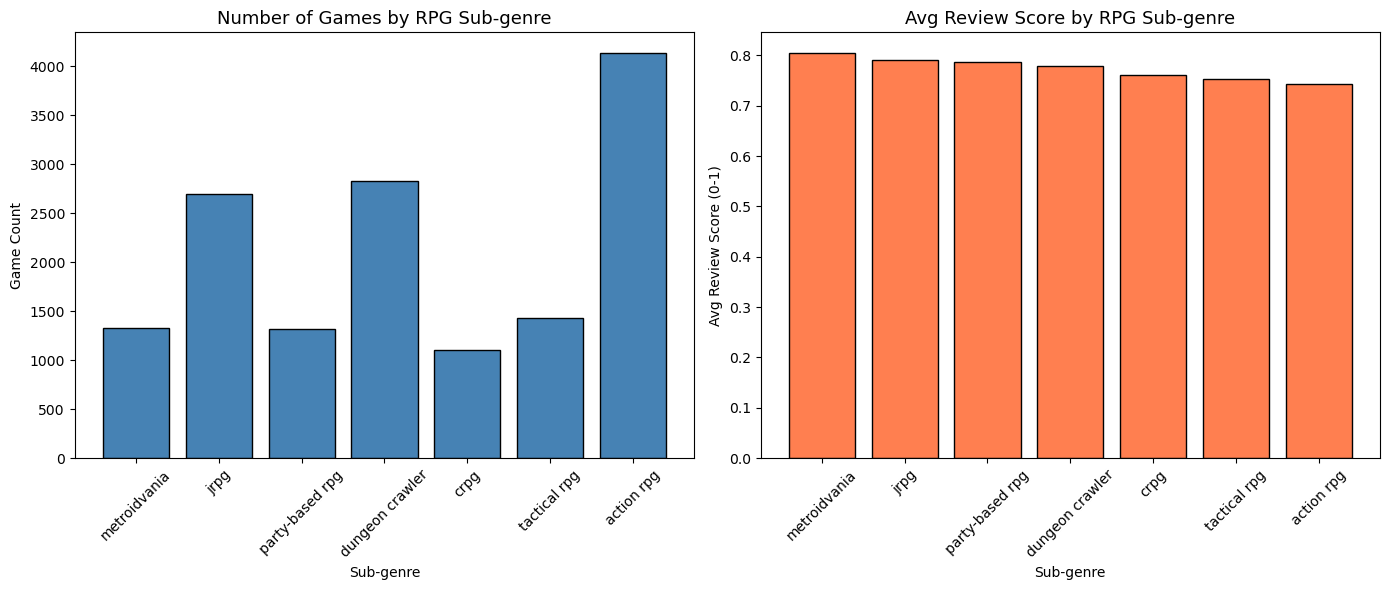

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(summary_df['subgenre'], summary_df['game_count'],
            color='steelblue', edgecolor='black')
axes[0].set_title('Number of Games by RPG Sub-genre', fontsize=13)
axes[0].set_xlabel('Sub-genre')
axes[0].set_ylabel('Game Count')
axes[0].tick_params(axis='x', rotation=45)
 
axes[1].bar(summary_df['subgenre'], summary_df['avg_review_score'],
            color='coral', edgecolor='black')
axes[1].set_title('Avg Review Score by RPG Sub-genre', fontsize=13)
axes[1].set_xlabel('Sub-genre')
axes[1].set_ylabel('Avg Review Score (0-1)')
axes[1].tick_params(axis='x', rotation=45)
 
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# OBJECTIVE 4: Most Popular Supported Languages
# ============================================================
# What languages should the game support beyond English?

In [20]:
lang_counter = Counter()
for entry in steam['supported_languages'].tolist():
    try:
        langs = ast.literal_eval(entry)
        for lang in langs:
            lang_counter[lang.strip()] += 1
    except:
        continue
 
lang_series = pd.Series(lang_counter).sort_values(ascending=False)
non_english = lang_series[lang_series.index.str.lower() != 'english'].head(10)

In [21]:
# Simplified Chinese has the highest number of non-English speakers,
# while Traditional Chinese is the lowest.
# Despite Simplified Chinese ranking highest, market barriers may
# limit accessibility for an indie studio.
#
# Among European languages, German, French and Spanish are close in numbers
# and are recommended as the priority languages after English.
# Japanese speakers are a sizeable group and worth noting.
#
# German, French and Spanish are recommended for their proximity to English,
# making translation less costly and time consuming than Chinese or Japanese.

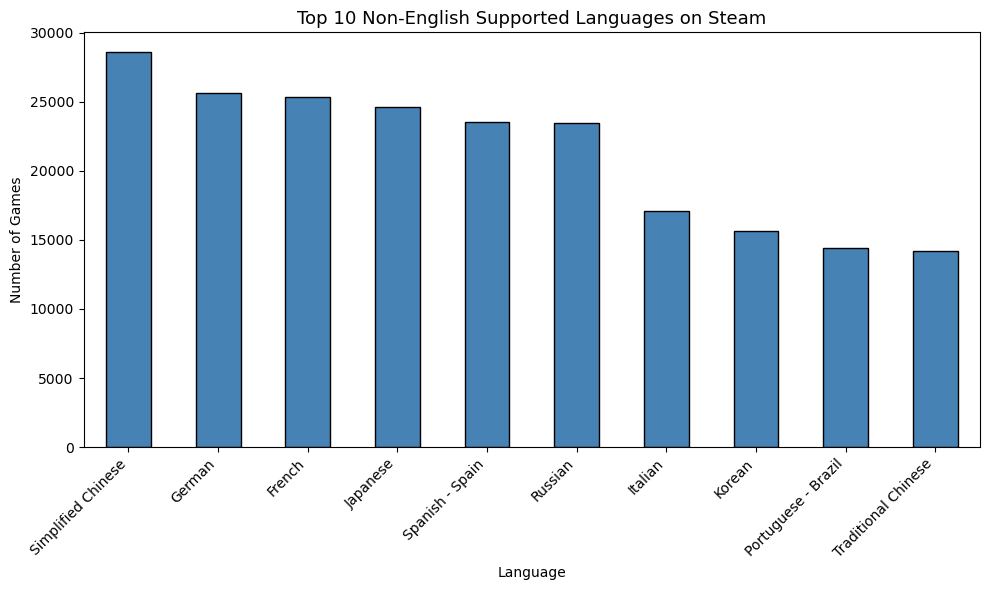

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
non_english.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 10 Non-English Supported Languages on Steam', fontsize=13)
ax.set_xlabel('Language')
ax.set_ylabel('Number of Games')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# OBJECTIVE 5: Should They Invest in Marketing?
# ============================================================
# The movies column has no data in this dataset.
# We use recommendations as a proxy for marketing visibility.

In [24]:
# The movies column contained no usable data, so an alternative
# approach was taken using recommendations and review scores
# as a proxy for visibility and market exposure.
#
# Recommendation counts vary widely, so they were grouped into
# tiers: Low (0-100), Medium (100-1K), High (1K-10K), Very High (10K+)
#
# The results are inconclusive — review scores and owner counts
# remain relatively flat across all recommendation tiers,
# suggesting recommendations alone don't drive success.
#
# This objective comes down to a simple business decision:
# Does the studio want visibility and market exposure?
# If yes, invest in marketing. The data neither confirms nor denies its impact.

In [25]:
steam['review_score'].unique()

array([0.98823529, 0.875     ,        nan, ..., 0.90829694, 0.84666667,
       0.71466578], shape=(17958,))

In [26]:
steam['recommendations'].unique()

array([ 231,    0,  107, ..., 1842, 5667, 4543], shape=(5314,))

In [27]:
steam['owners_mid'].unique()

array([1.0e+04, 1.5e+05, 7.5e+05, 3.5e+04, 3.5e+05, 7.5e+04, 3.5e+06,
       1.5e+07, 1.5e+06, 3.5e+07, 7.5e+06, 1.5e+08, 7.5e+07])


--- Recommendations Impact ---
                  owners_mid  review_score
rec_tier                                  
Medium (100-1K)      35000.0      0.821311
High (1K-10K)       150000.0      0.868331
Very High (10K+)   1500000.0      0.901151
owners_mid      float64
review_score    float64
dtype: object


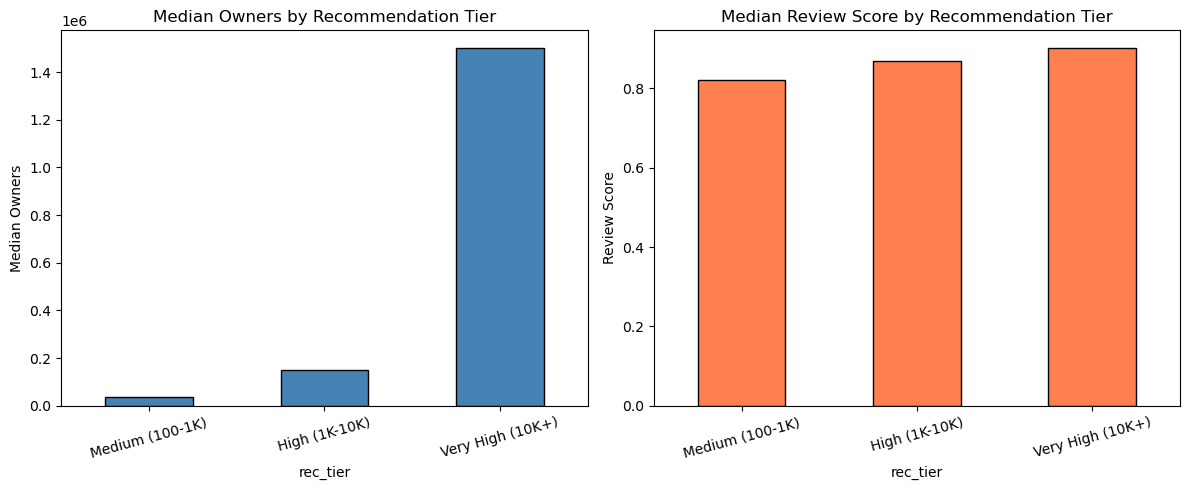

In [28]:
steam['rec_tier'] = pd.cut(
    steam['recommendations'],
    bins=[0, 100, 1000, 10000, float('inf')],
    labels=['Low (0-100)', 'Medium (100-1K)', 'High (1K-10K)', 'Very High (10K+)']
)
 
rec_summary = (steam.groupby('rec_tier', observed=True)[['owners_mid', 'review_score']]
                    .median()
                    .dropna())
 
print("\n--- Recommendations Impact ---")
print(rec_summary)
print(rec_summary.dtypes)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
rec_summary['owners_mid'].plot(kind='bar', ax=axes[0],
                               color='steelblue', edgecolor='black')
axes[0].set_title('Median Owners by Recommendation Tier')
axes[0].set_ylabel('Median Owners')
axes[0].tick_params(axis='x', rotation=15)
 
rec_summary['review_score'].plot(kind='bar', ax=axes[1],
                                 color='coral', edgecolor='black')
axes[1].set_title('Median Review Score by Recommendation Tier')
axes[1].set_ylabel('Review Score')
axes[1].tick_params(axis='x', rotation=15)
 
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# OBJECTIVE 6: Should They Include DLC?
# ============================================================
# No microtransaction tag exists in this dataset.
# We compare games with DLC vs without DLC.

In [30]:
# The team decided not to invest in microtransactions, considering it
# unfair to the player.
# However, the studio wants to know whether DLC is worth implementing.
#
# Much like Objective 5, the data here is inconclusive.
# Both graphs show little difference between games with and without DLC,
# and the review score difference is marginal at best.
#
# This comes down to a simple business decision:
# Does the studio want to extend their game's life with additional content?
# If yes, implement DLC — the data shows no negative impact from doing so.

In [31]:
has_dlc = steam[ steam['has_dlc']]
no_dlc  = steam[~steam['has_dlc']]
 
dlc_summary = pd.DataFrame({
    'Group': ['Has DLC', 'No DLC'],
    'median_owners':    [has_dlc['owners_mid'].dropna().median(),
                         no_dlc['owners_mid'].dropna().median()],
    'avg_review_score': [has_dlc['review_score'].dropna().mean(),
                         no_dlc['review_score'].dropna().mean()]
})
 
print("\n--- DLC Impact ---")
print(dlc_summary.to_string(index=False))


--- DLC Impact ---
  Group  median_owners  avg_review_score
Has DLC        10000.0          0.805880
 No DLC        10000.0          0.748528


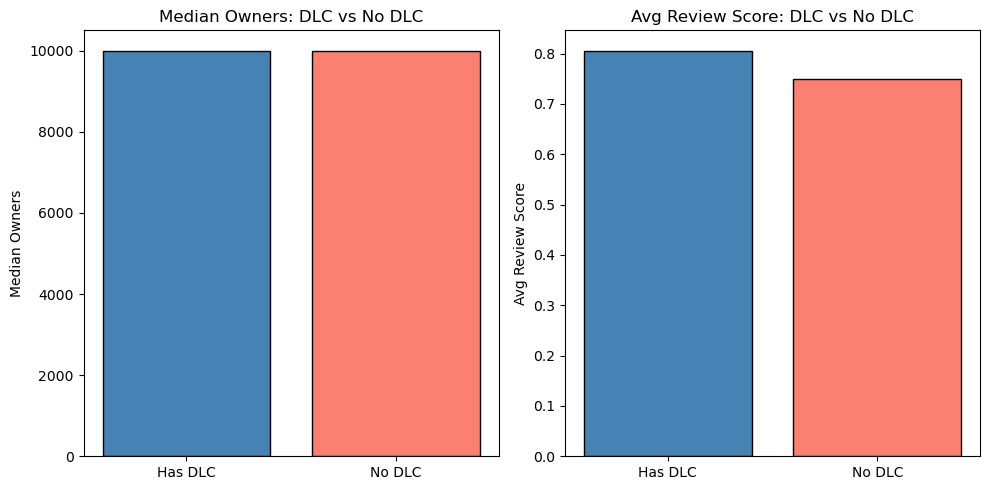

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = ['steelblue', 'salmon']
 
axes[0].bar(dlc_summary['Group'], dlc_summary['median_owners'],
            color=colors, edgecolor='black')
axes[0].set_title('Median Owners: DLC vs No DLC')
axes[0].set_ylabel('Median Owners')
axes[0].tick_params(axis='x', rotation=0)
 
axes[1].bar(dlc_summary['Group'], dlc_summary['avg_review_score'],
            color=colors, edgecolor='black')
axes[1].set_title('Avg Review Score: DLC vs No DLC')
axes[1].set_ylabel('Avg Review Score')
axes[1].tick_params(axis='x', rotation=0)
 
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# OBJECTIVE 7: Best Time to Release
# ============================================================
# owners_mid is unreliable for timing due to range-based data.
# We use game count per period as a proxy for optimal release windows.

In [ ]:
# This objective is separated into three parts: Month, Day of Week, and Quarter.
# The goal is to find the best time of year to release the studio's game.
#
# Note: Due to owner data being stored as ranges, game count per period
# is used as a proxy for optimal release windows.
#
# By month, October and November show the highest release activity,
# both falling within Q4.
# By day of week, Thursday sees the most releases with Friday a close second.
# Saturday and Sunday have the lowest release counts and should be avoided.
#
# Recommendation: Release the game on a Thursday in October.
# This aligns with the most active release window on Steam
# and maximizes visibility during the Q4 gaming season.

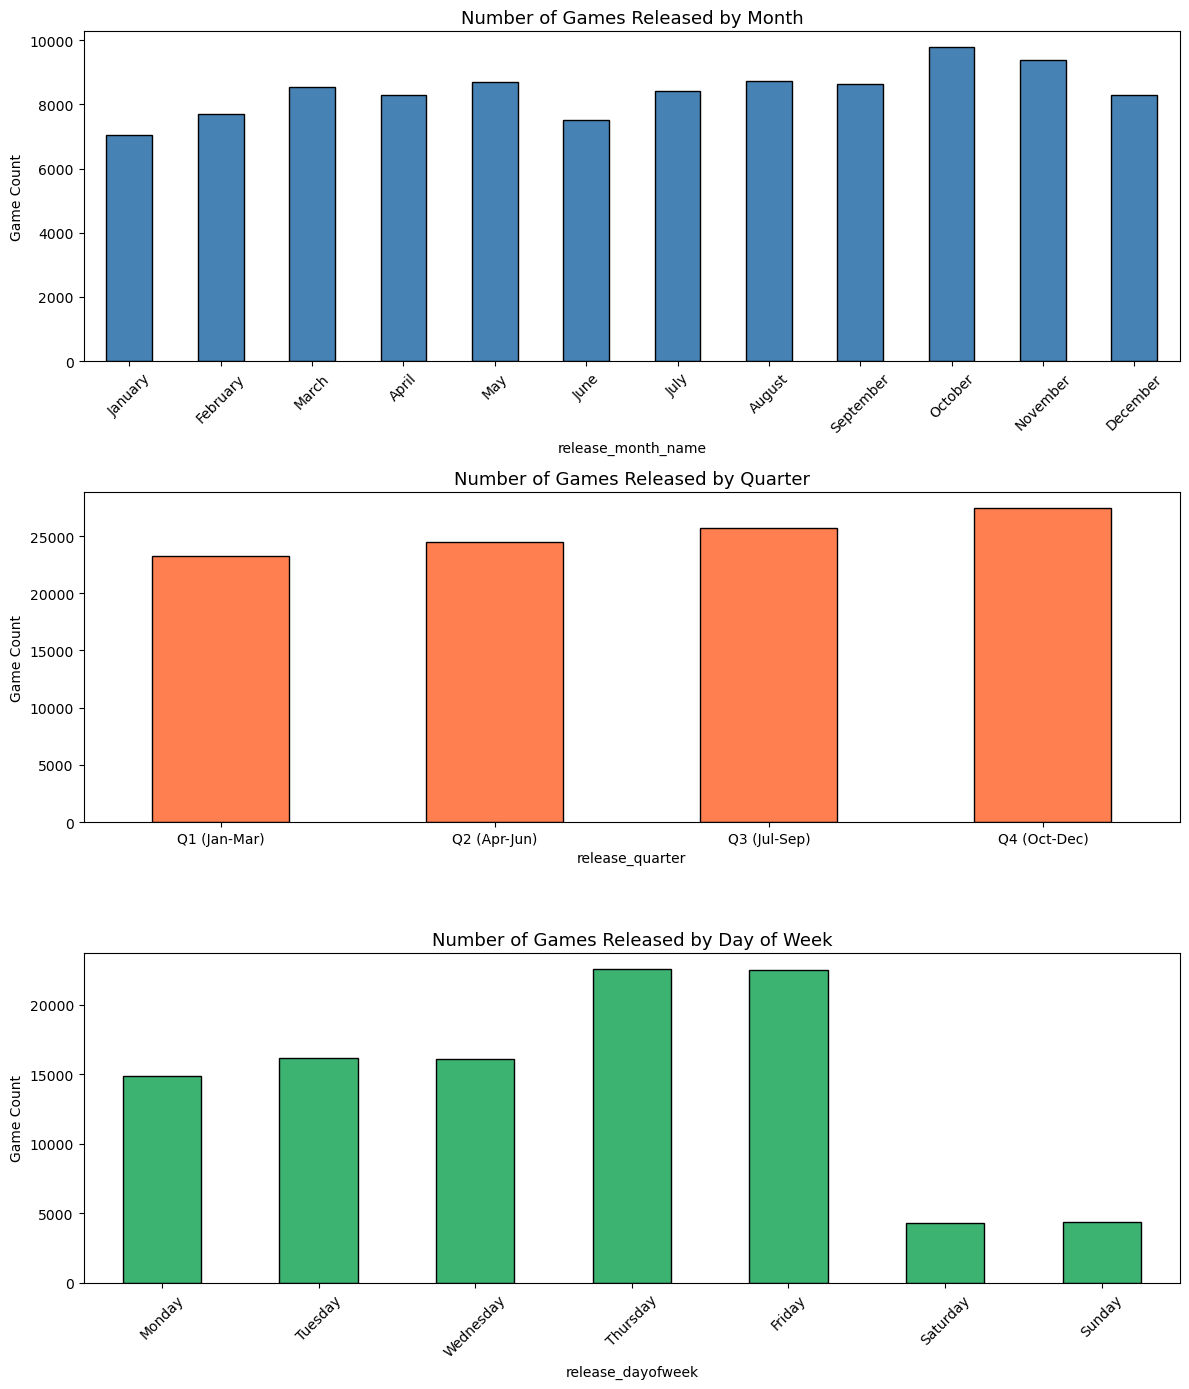


Most popular release month:   October
Most popular release quarter: Q4 (Oct-Dec)
Most popular release day:     Thursday


In [34]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
 
quarter_names = {1: 'Q1 (Jan-Mar)', 2: 'Q2 (Apr-Jun)',
                 3: 'Q3 (Jul-Sep)', 4: 'Q4 (Oct-Dec)'}
 
monthly   = steam['release_month_name'].value_counts().reindex(month_order).dropna()
quarterly = steam['release_quarter'].value_counts().sort_index()
quarterly.index = quarterly.index.map(quarter_names)
daily     = steam['release_dayofweek'].value_counts().reindex(day_order).dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
 
monthly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Number of Games Released by Month', fontsize=13)
axes[0].set_ylabel('Game Count')
axes[0].tick_params(axis='x', rotation=45)
 
quarterly.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Number of Games Released by Quarter', fontsize=13)
axes[1].set_ylabel('Game Count')
axes[1].tick_params(axis='x', rotation=0)
 
daily.plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Number of Games Released by Day of Week', fontsize=13)
axes[2].set_ylabel('Game Count')
axes[2].tick_params(axis='x', rotation=45)
 
plt.tight_layout()
plt.show()
 
print(f"\nMost popular release month:   {monthly.idxmax()}")
print(f"Most popular release quarter: {quarterly.idxmax()}")
print(f"Most popular release day:     {daily.idxmax()}")
 